<a href="https://colab.research.google.com/github/yashc2003/ML_DL_Practice_Projects/blob/main/Breast_Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Breast Cancer Prediction using Artificial Neural Network (ANN)



In [ ]:
#Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
# load dataset
df = pd.read_csv("breastcancer.csv")

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
# data prossesing

df = df.drop("id", axis=1)

In [ ]:
# convert target
encoder = LabelEncoder()

df["diagnosis"] = encoder.fit_transform(df["diagnosis"])

In [ ]:
df.isnull().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


In [ ]:
# split feature and targat
X = df.drop("diagnosis", axis=1)

y = df["diagnosis"]

In [ ]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

In [ ]:
#feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
#ANN model
model = Sequential()

model.add(Dense(64,

                activation='relu',

                input_shape=(30,)))

model.add(Dense(32,

                activation='relu'))

model.add(Dense(16,

                activation='relu'))

model.add(Dense(1,

                activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']

)

In [ ]:
# train model
history = model.fit(

    X_train,

    y_train,

    epochs=50,

    batch_size=32,

    validation_split=0.2

)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.6236 - loss: 0.6599 - val_accuracy: 0.9121 - val_loss: 0.4971
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9093 - loss: 0.4214 - val_accuracy: 0.9341 - val_loss: 0.3164
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9286 - loss: 0.2664 - val_accuracy: 0.9451 - val_loss: 0.2088
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9533 - loss: 0.1794 - val_accuracy: 0.9451 - val_loss: 0.1537
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9670 - loss: 0.1284 - val_accuracy: 0.9560 - val_loss: 0.1231
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9725 - loss: 0.1010 - val_accuracy: 0.9670 - val_loss: 0.1082
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9780 - loss: 0.0801 - val_accuracy: 0.9670 - val_loss: 0.0983
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9835 - loss: 0.0674 - val_accuracy: 0.9670 - v

In [ ]:
# Evalueate
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy :", accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9825 - loss: 0.1142
Accuracy : 0.9824561476707458


In [ ]:
# Prediction
y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


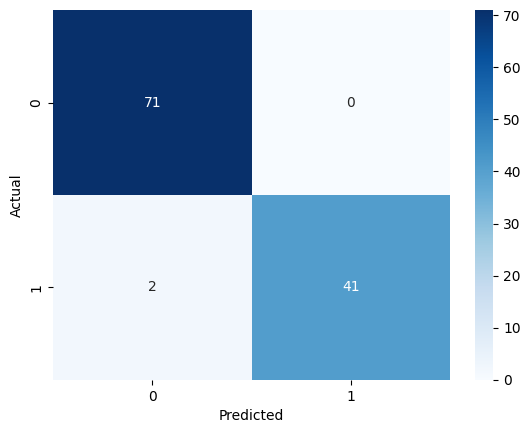

In [ ]:
# confusion matrics
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm,

            annot=True,

            fmt='d',

            cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
diagnosis_counts = df["diagnosis"].value_counts()

print(diagnosis_counts)

diagnosis
0    357
1    212
Name: count, dtype: int64


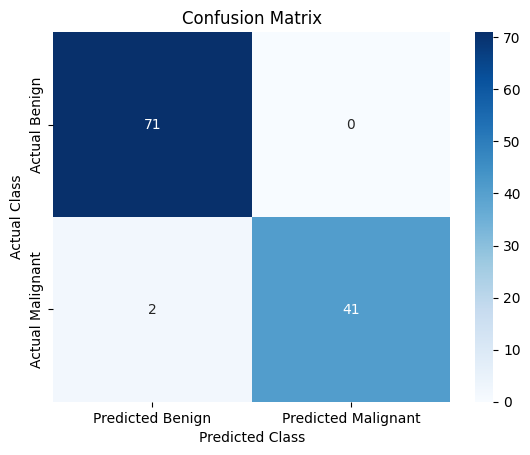

In [ ]:
import seaborn as sns
sns.heatmap(cm_df,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [ ]:
import pandas as pd

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Give row and column names
cm_df = pd.DataFrame(
    cm,
    index=["Actual Benign", "Actual Malignant"],
    columns=["Predicted Benign", "Predicted Malignant"]
)

print("\n===== Confusion Matrix =====")
print(cm_df)


===== Confusion Matrix =====
                  Predicted Benign  Predicted Malignant
Actual Benign                   71                    0
Actual Malignant                 2                   41


In [ ]:
# classifiction report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        71
           1       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [ ]:
# accuracy
print("Accuracy Score :",

      accuracy_score(y_test, y_pred))

Accuracy Score : 0.9824561403508771


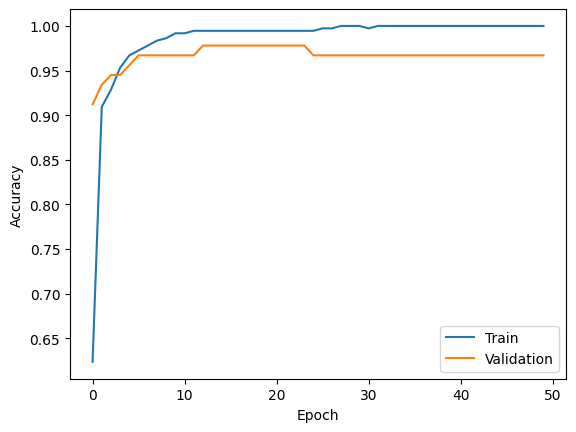

In [ ]:
# accuracy graph
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.legend(['Train','Validation'])

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.show()

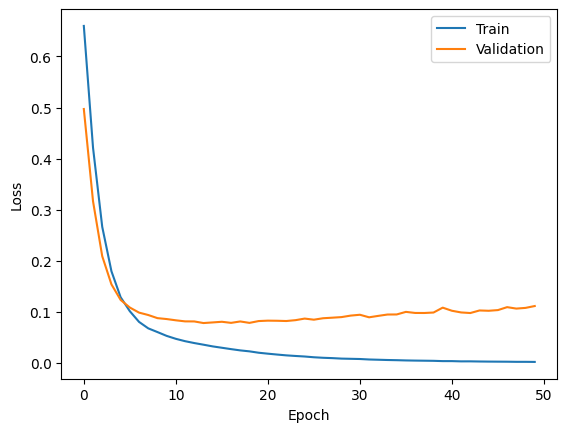

In [ ]:
# loss graph
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.legend(['Train','Validation'])

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()